# 01. Arabidopsis Public-Reference Explorer

This notebook reviews the cross-dataset label-transfer workflow that will later support hypothesis generation for *Wolffia australiana* PIP-seq data.

## Goal

Use one Arabidopsis single-cell dataset as a training reference, transfer broad expression-program labels to an independent Arabidopsis dataset, and evaluate whether those programs remain distinguishable across studies.

## Default comparison

- **Training reference:** GSE227564 callus
- **Test dataset:** GSE141730 phosphate-treated root
- **Model:** class-balanced logistic regression after PCA
- **Unit of prediction:** broad plant expression program, not a definitive cell type

> A predicted program is a computational hypothesis. UMAP structure, program scores, and cross-dataset consistency can support that hypothesis, but they do not replace independent annotation or experimental validation.

## 1. Setup

Run the notebook from top to bottom. The imports below provide single-cell data handling, plotting, numerical summaries, and simple quantitative diagnostics.

An `AnnData` object stores cells as rows, genes as columns, cell metadata in `.obs`, gene metadata in `.var`, and reduced coordinates such as PCA or UMAP in `.obsm`.

In [1]:
from __future__ import annotations

import json
import os
from pathlib import Path

os.environ.setdefault("NUMBA_CACHE_DIR", "/private/tmp/numba-cache")
os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/mplconfig")

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import yaml
from IPython.display import Markdown, display
from scipy import sparse
from scipy.spatial.distance import jensenshannon
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

plt.rcParams["figure.figsize"] = (7, 5)
sns.set_context("talk")
sns.set_style("whitegrid")
pd.set_option("display.max_colwidth", 120)

### Locate the project

The notebook searches upward from the current working directory and then checks the known local project path. This prevents the earlier `FileNotFoundError` when Jupyter is launched from a different folder.

In [2]:
KNOWN_REPO_ROOT = Path("/Users/bella/Documents/Wolffia Single-Cell Atlas Pipeline Before the Data Arrive")

def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "config" / "config.yaml").exists() and (candidate / "results").exists():
            return candidate
    if (KNOWN_REPO_ROOT / "config" / "config.yaml").exists() and (KNOWN_REPO_ROOT / "results").exists():
        return KNOWN_REPO_ROOT
    raise FileNotFoundError("Could not find the project root containing config/config.yaml and results/")

REPO_ROOT = find_repo_root(Path.cwd().resolve())
CONFIG_PATH = REPO_ROOT / "config" / "config.yaml"

with open(CONFIG_PATH) as fh:
    config = yaml.safe_load(fh)

AVAILABLE_RESULT_DIRS = sorted(path for path in REPO_ROOT.glob("results/public_reference*") if path.is_dir())
print("Repository root:", REPO_ROOT)
print("Available completed analyses:")
for result_path in AVAILABLE_RESULT_DIRS:
    print(" -", result_path.relative_to(REPO_ROOT))

Repository root: /Users/bella/Documents/Wolffia Single-Cell Atlas Pipeline Before the Data Arrive
Available completed analyses:
 - results/public_reference
 - results/public_reference_gse121619
 - results/public_reference_gse123818
 - results/public_reference_gse123818_shr
 - results/public_reference_gse123818_wt_train_to_gse121619
 - results/public_reference_gse123818_wt_train_to_shr


## 2. Select and inspect one analysis

`public_reference` is the default callus-to-phosphate-root transfer. Change `RESULT_DIR_NAME` to inspect another completed run.

The `.h5ad` files contain expression and cell metadata. The JSON and CSV files contain model settings, prediction counts, marker recovery, and cluster-level program assignments.

In [3]:
RESULT_DIR_NAME = "public_reference"
RESULT_DIR = REPO_ROOT / "results" / RESULT_DIR_NAME

TRAIN_H5AD = RESULT_DIR / "train_reference_scored.h5ad"
TEST_H5AD = RESULT_DIR / "test_reference_scored.h5ad"
METRICS_JSON = RESULT_DIR / "cross_dataset_metrics.json"
PREDICTED_COUNTS_CSV = RESULT_DIR / "predicted_label_counts.csv"
TRAIN_ASSIGNMENTS_CSV = RESULT_DIR / "train_cluster_program_assignments.csv"
TRAIN_MARKER_RECOVERY_CSV = RESULT_DIR / "train_marker_recovery.csv"
TEST_MARKER_RECOVERY_CSV = RESULT_DIR / "test_marker_recovery.csv"

required_paths = [TRAIN_H5AD, TEST_H5AD, METRICS_JSON, PREDICTED_COUNTS_CSV]
missing_paths = [path for path in required_paths if not path.exists()]
if missing_paths:
    raise FileNotFoundError("Missing required outputs: " + ", ".join(str(path) for path in missing_paths))

with open(METRICS_JSON) as fh:
    metrics = json.load(fh)

predicted_counts = pd.read_csv(PREDICTED_COUNTS_CSV)
train_assignments = pd.read_csv(TRAIN_ASSIGNMENTS_CSV) if TRAIN_ASSIGNMENTS_CSV.exists() else None
train_marker_recovery = pd.read_csv(TRAIN_MARKER_RECOVERY_CSV)
test_marker_recovery = pd.read_csv(TEST_MARKER_RECOVERY_CSV)

display(pd.DataFrame([metrics]))
display(predicted_counts)
if train_assignments is not None:
    display(train_assignments.head(10))

,classifier,train_dataset_name,test_dataset_name,n_train_cells,n_test_cells,n_selected_genes,selected_genes_preview,labels_used,test_label_mode
0,logistic_regression,GSE227564_callus,GSE141730_root_phosphate,1500,2000,2000,"[AT1G01070, AT1G02190, AT1G02360, AT1G02380, AT1G03220, AT1G03440, AT1G03620, AT1G03660, AT1G03700, AT1G03820, AT1G0...","[abiotic_stress_response, epidermal_or_surface_identity, proliferative_or_meristematic, transport_interface_or_water...",unlabeled


,predicted_broad_program,n_cells
0,abiotic_stress_response,1557
1,transport_interface_or_water_balance,418
2,vascular_like_or_transport,16
3,proliferative_or_meristematic,9


,cluster_label,assigned_program,top_program,top_score,second_score,score_margin
0,0,abiotic_stress_response,abiotic_stress_response,0.760123,0.333471,0.426652
1,1,transport_interface_or_water_balance,transport_interface_or_water_balance,0.710460,0.210064,0.500396
2,10,transport_interface_or_water_balance,transport_interface_or_water_balance,0.658452,0.597360,0.061091
3,11,transport_interface_or_water_balance,transport_interface_or_water_balance,0.198709,0.175992,0.022716
4,12,abiotic_stress_response,abiotic_stress_response,0.356983,0.023302,0.333682
5,13,vascular_like_or_transport,vascular_like_or_transport,0.559539,0.213418,0.346121
6,14,transport_interface_or_water_balance,transport_interface_or_water_balance,0.901857,0.111033,0.790824
7,15,transport_interface_or_water_balance,transport_interface_or_water_balance,1.045369,0.325781,0.719588
8,16,transport_interface_or_water_balance,transport_interface_or_water_balance,0.723994,0.034334,0.689659
9,17,abiotic_stress_response,abiotic_stress_response,0.153001,0.010941,0.142059


### How to read these tables

- `n_train_cells` and `n_test_cells` are the modeled cells after filtering and optional subsampling; they may be smaller than the source `.h5ad` objects.
- `labels_used` lists the programs the model was allowed to predict.
- `test_label_mode = unlabeled` means formal test accuracy cannot be calculated for this run.
- Prediction counts describe the modeled subset, not the biological abundance of cell types in the original organism.

In [4]:
train = sc.read_h5ad(TRAIN_H5AD)
test_full = sc.read_h5ad(TEST_H5AD)

prediction_column = "predicted_broad_program"
if prediction_column not in test_full.obs:
    raise KeyError(f"{prediction_column!r} is missing from the saved test object")

# Only cells used by the classifier have a non-missing prediction.
test_predicted = test_full[test_full.obs[prediction_column].notna()].copy()
test_predicted.obs[prediction_column] = test_predicted.obs[prediction_column].astype(str)

print(f"Training object: {train.n_obs:,} cells x {train.n_vars:,} genes")
print(f"Full test object: {test_full.n_obs:,} cells x {test_full.n_vars:,} genes")
print(f"Predicted test subset: {test_predicted.n_obs:,} cells x {test_predicted.n_vars:,} genes")
print(f"Metrics file reports: {metrics['n_test_cells']:,} modeled test cells")

assert test_predicted.n_obs == int(metrics["n_test_cells"]), "Saved predictions do not match the reported modeled cell count."
assert test_predicted.n_obs == int(predicted_counts["n_cells"].sum()), "Prediction CSV counts do not match the saved predictions."

display(Markdown(
    f"**Data check passed:** all three sources agree that **{test_predicted.n_obs:,} test cells** received predictions. "
    f"The remaining **{test_full.n_obs - test_predicted.n_obs:,} source cells** were not modeled and are excluded from prediction plots."
))

Training object: 3,987 cells x 29,116 genes
Full test object: 5,145 cells x 34,262 genes
Predicted test subset: 2,000 cells x 34,262 genes
Metrics file reports: 2,000 modeled test cells


**Data check passed:** all three sources agree that **2,000 test cells** received predictions. The remaining **3,145 source cells** were not modeled and are excluded from prediction plots.

## 3. Visualization and comparison helpers

The saved training object already contains PCA and UMAP coordinates. The predicted test subset does not, so the helper computes them from the normalized expression matrix.

### What UMAP means

UMAP compresses thousands of gene-expression measurements into two dimensions. Nearby points tend to have more similar expression profiles, but UMAP axes have no direct biological units. Apparent islands or distances can change with preprocessing and parameter choices. UMAP supports visual exploration; it does not prove cell identity, lineage, or developmental direction.

### Quantitative diagnostics

- **PCA silhouette score:** compares within-label compactness with between-label separation. Values near 1 indicate strong separation, around 0 indicate overlap, and below 0 indicate substantial mixing. It is descriptive here, not an accuracy score.
- **Local neighbor agreement:** fraction of nearby cells in PCA space sharing the same label. Higher values indicate locally coherent predictions, but can also reflect a dominant label.
- **Top-two score margin:** difference between the strongest and second-strongest marker-module score. Small margins flag ambiguous or mixed program activity.

In [5]:
def ensure_embeddings(
    adata: ad.AnnData,
    n_top_hvgs: int = 2000,
    n_pcs: int = 30,
    n_neighbors: int = 15,
    random_state: int = 42,
) -> ad.AnnData:
    adata = adata.copy()
    if "X_pca" not in adata.obsm:
        sc.pp.highly_variable_genes(adata, n_top_genes=min(n_top_hvgs, adata.n_vars), flavor="seurat")
        use_data = adata[:, adata.var["highly_variable"]].copy() if "highly_variable" in adata.var else adata.copy()
        sc.pp.scale(use_data, max_value=10)
        n_components = min(n_pcs, use_data.n_vars, max(2, use_data.n_obs - 1))
        sc.tl.pca(use_data, n_comps=n_components, random_state=random_state)
        adata.obsm["X_pca"] = use_data.obsm["X_pca"]
    if "X_umap" not in adata.obsm:
        usable_pcs = min(n_pcs, adata.obsm["X_pca"].shape[1])
        usable_neighbors = min(n_neighbors, max(2, adata.n_obs - 1))
        sc.pp.neighbors(adata, n_neighbors=usable_neighbors, n_pcs=usable_pcs)
        sc.tl.umap(adata, random_state=random_state)
    return adata


def program_score_columns(adata: ad.AnnData) -> list[str]:
    return [column for column in adata.obs.columns if column.endswith("_score")]


def plot_program_heatmap(adata: ad.AnnData, group_col: str) -> pd.DataFrame:
    score_columns = program_score_columns(adata)
    summary = adata.obs[[group_col, *score_columns]].copy()
    summary[group_col] = summary[group_col].astype(str)
    heatmap_data = summary.groupby(group_col, observed=True)[score_columns].mean()
    heatmap_data.columns = [column.removesuffix("_score") for column in heatmap_data.columns]
    plt.figure(figsize=(1.25 * len(heatmap_data.columns), 0.8 * max(3, len(heatmap_data))))
    sns.heatmap(heatmap_data, cmap="viridis", annot=True, fmt=".2f")
    plt.title(f"Mean marker-module scores by {group_col}")
    plt.xlabel("Marker module")
    plt.ylabel("Assigned group")
    plt.tight_layout()
    plt.show()
    return heatmap_data


def label_diagnostics(adata: ad.AnnData, label_col: str, n_neighbors: int = 15) -> dict[str, float]:
    labels = adata.obs[label_col].astype(str).to_numpy()
    coordinates = np.asarray(adata.obsm["X_pca"])
    counts = pd.Series(labels).value_counts()
    valid = np.array([counts[label] >= 2 for label in labels])
    silhouette = np.nan
    if valid.sum() > counts.size and counts[counts >= 2].size > 1:
        silhouette = float(silhouette_score(coordinates[valid], labels[valid], sample_size=min(3000, valid.sum()), random_state=42))
    k = min(n_neighbors + 1, adata.n_obs)
    neighbor_indices = NearestNeighbors(n_neighbors=k).fit(coordinates).kneighbors(return_distance=False)[:, 1:]
    agreement = float(np.mean(labels[neighbor_indices] == labels[:, None]))
    return {"pca_silhouette": silhouette, "local_neighbor_agreement": agreement}


def score_margin_summary(adata: ad.AnnData) -> dict[str, float]:
    scores = adata.obs[program_score_columns(adata)].to_numpy(dtype=float)
    ordered = np.sort(scores, axis=1)
    margins = ordered[:, -1] - ordered[:, -2]
    return {
        "median_margin": float(np.median(margins)),
        "lower_quartile": float(np.quantile(margins, 0.25)),
        "upper_quartile": float(np.quantile(margins, 0.75)),
    }

train_viz = ensure_embeddings(train)
test_viz = ensure_embeddings(test_predicted)

/opt/anaconda3/envs/py311/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


## 4. Training-reference plots

The training UMAP is colored by the broad program used as the model target. If source labels are available, the second UMAP shows their finer-grained annotation. Coherent regions suggest that the broad programs correspond to real expression structure; mixing suggests related, continuous, or weakly separable states.

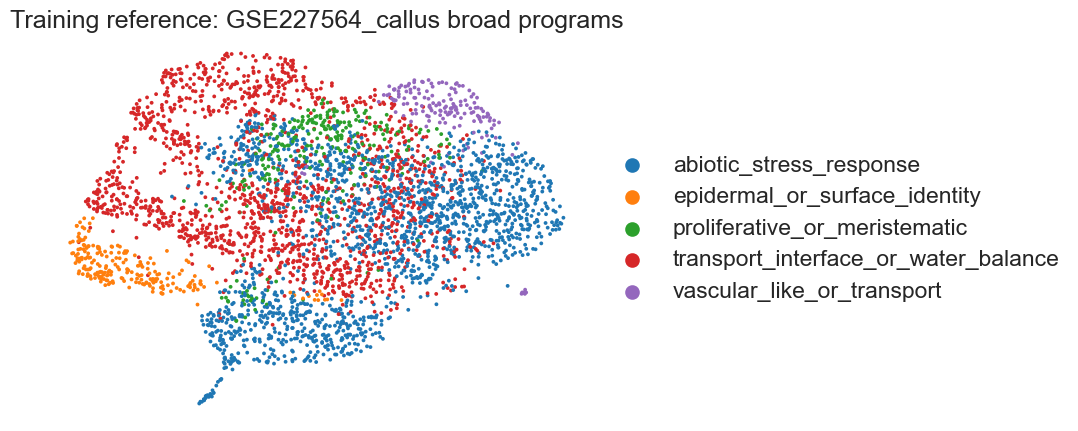

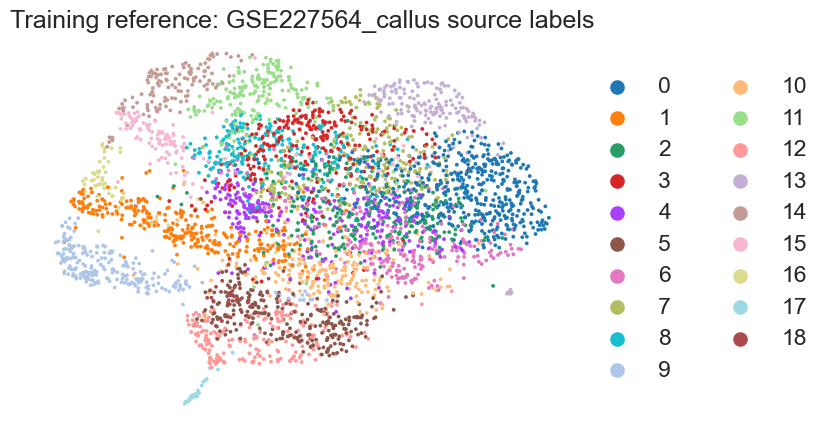

In [6]:
sc.pl.umap(
    train_viz,
    color="broad_program",
    title=f"Training reference: {metrics['train_dataset_name']} broad programs",
    frameon=False,
    show=True,
)
if "original_label" in train_viz.obs.columns:
    sc.pl.umap(
        train_viz,
        color="original_label",
        title=f"Training reference: {metrics['train_dataset_name']} source labels",
        frameon=False,
        legend_loc="right margin",
        show=True,
    )

In [7]:
train_diagnostics = label_diagnostics(train_viz, "broad_program")
train_margins = score_margin_summary(train_viz)
train_distribution = train_viz.obs["broad_program"].astype(str).value_counts(normalize=True)
train_top_label = train_distribution.index[0]
train_top_share = train_distribution.iloc[0]

display(Markdown(f"""
### Interpretation: training UMAP

- The largest training program is **{train_top_label}** ({train_top_share:.1%} of training cells), so the reference is imbalanced even though the classifier uses class weights.
- The PCA silhouette score is **{train_diagnostics['pca_silhouette']:.2f}**. Values near zero indicate that broad programs overlap in global expression space; positive values indicate increasing separation.
- Local neighbor agreement is **{train_diagnostics['local_neighbor_agreement']:.1%}**. This measures local coherence, but it should be read alongside class imbalance because a common label can inflate agreement.
- The median top-two marker-score margin is **{train_margins['median_margin']:.2f}** (middle 50%: {train_margins['lower_quartile']:.2f} to {train_margins['upper_quartile']:.2f}). Smaller margins indicate cells with competing program signals.

Together, these diagnostics describe how learnable the training labels appear. They do not measure transfer accuracy on the unlabeled test dataset.
"""))


### Interpretation: training UMAP

- The largest training program is **abiotic_stress_response** (44.2% of training cells), so the reference is imbalanced even though the classifier uses class weights.
- The PCA silhouette score is **0.02**. Values near zero indicate that broad programs overlap in global expression space; positive values indicate increasing separation.
- Local neighbor agreement is **79.9%**. This measures local coherence, but it should be read alongside class imbalance because a common label can inflate agreement.
- The median top-two marker-score margin is **0.31** (middle 50%: 0.12 to 0.59). Smaller margins indicate cells with competing program signals.

Together, these diagnostics describe how learnable the training labels appear. They do not measure transfer accuracy on the unlabeled test dataset.


### Training marker-module heatmap

Rows are assigned broad programs and columns are marker modules. A strong diagonal pattern supports internal consistency: cells assigned to one program should, on average, score highly for the matching marker set. Bright off-diagonal cells indicate shared markers, mixed states, or categories that may be difficult to distinguish.

/var/folders/w0/v9yy8dh97l5cbw6kwc8v949m0000gn/T/ipykernel_58170/2806671354.py:39: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


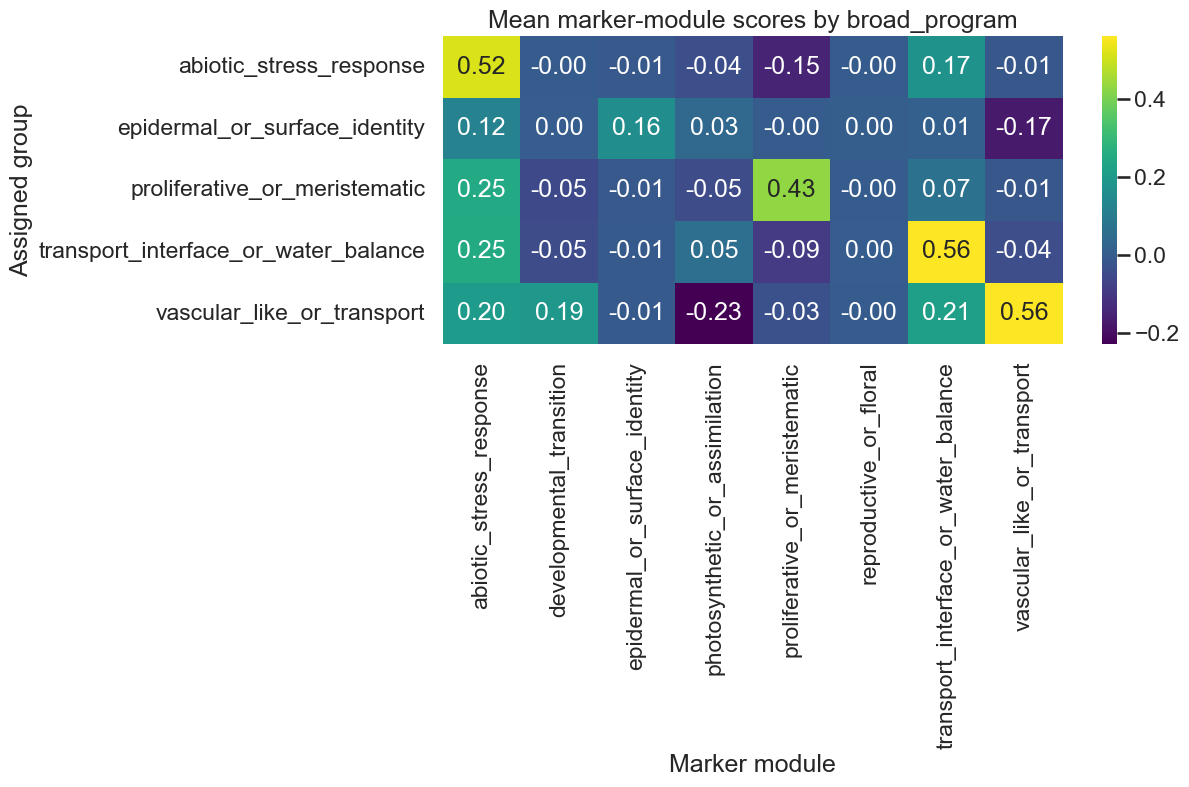

,assigned_program,highest_scoring_module,highest_score,second_module,score_gap,matches_assignment
0,abiotic_stress_response,abiotic_stress_response,0.515120,transport_interface_or_water_balance,0.342006,True
1,epidermal_or_surface_identity,epidermal_or_surface_identity,0.158632,abiotic_stress_response,0.037483,True
2,proliferative_or_meristematic,proliferative_or_meristematic,0.430101,abiotic_stress_response,0.184006,True
3,transport_interface_or_water_balance,transport_interface_or_water_balance,0.559361,abiotic_stress_response,0.310029,True
4,vascular_like_or_transport,vascular_like_or_transport,0.559539,transport_interface_or_water_balance,0.346121,True


**Heatmap interpretation:** 100% of assigned training groups have their matching marker module as the highest mean score. Rows with a different top module or a small score gap deserve special scrutiny because their biological labels are less distinct under the current marker panel.

In [8]:
train_score_heatmap = plot_program_heatmap(train_viz, "broad_program")

row_summaries = []
for assigned_program, row in train_score_heatmap.iterrows():
    ranked = row.sort_values(ascending=False)
    row_summaries.append({
        "assigned_program": assigned_program,
        "highest_scoring_module": ranked.index[0],
        "highest_score": ranked.iloc[0],
        "second_module": ranked.index[1],
        "score_gap": ranked.iloc[0] - ranked.iloc[1],
        "matches_assignment": assigned_program == ranked.index[0],
    })
train_heatmap_check = pd.DataFrame(row_summaries)
display(train_heatmap_check)
match_rate = train_heatmap_check["matches_assignment"].mean()
display(Markdown(
    f"**Heatmap interpretation:** {match_rate:.0%} of assigned training groups have their matching marker module as the highest mean score. "
    "Rows with a different top module or a small score gap deserve special scrutiny because their biological labels are less distinct under the current marker panel."
))

## 5. Predicted test plots

Only cells with a non-missing `predicted_broad_program` are plotted. This fixes the earlier mismatch where the full source object was colored by its `unlabeled` field even though only a subsample received classifier predictions.

Look for local coherence, representation of multiple programs, and whether prediction boundaries follow the expression structure. A visually coherent UMAP is encouraging, but coherence can still arise from technical batch structure or broad treatment effects.

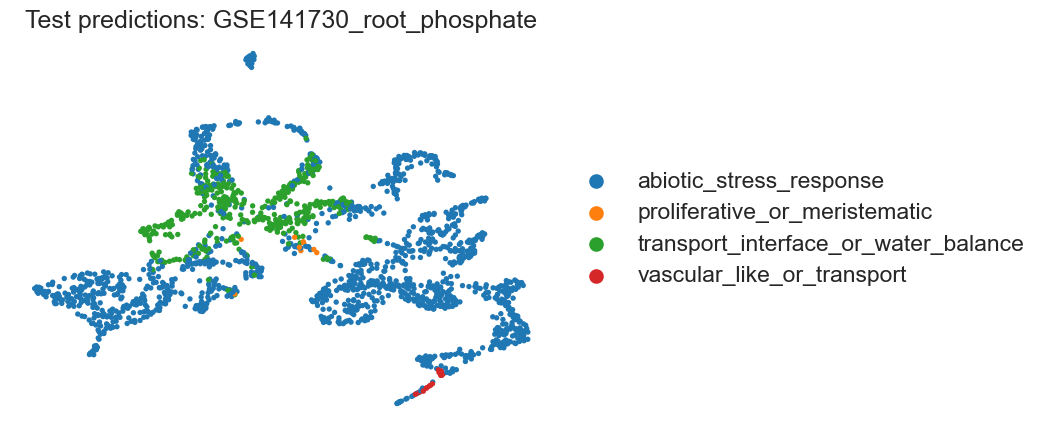

In [9]:
sc.pl.umap(
    test_viz,
    color=prediction_column,
    title=f"Test predictions: {metrics['test_dataset_name']}",
    frameon=False,
    show=True,
)

In [10]:
test_diagnostics = label_diagnostics(test_viz, prediction_column)
test_margins = score_margin_summary(test_viz)
test_distribution = test_viz.obs[prediction_column].astype(str).value_counts(normalize=True)
test_top_label = test_distribution.index[0]
test_top_share = test_distribution.iloc[0]

display(Markdown(f"""
### Interpretation: predicted test UMAP

- The dominant prediction is **{test_top_label}** ({test_top_share:.1%} of modeled test cells).
- The PCA silhouette score is **{test_diagnostics['pca_silhouette']:.2f}**, describing separation of predicted labels in expression space.
- Local neighbor agreement is **{test_diagnostics['local_neighbor_agreement']:.1%}**, describing whether nearby cells tend to receive the same prediction.
- The median marker-score margin is **{test_margins['median_margin']:.2f}** (middle 50%: {test_margins['lower_quartile']:.2f} to {test_margins['upper_quartile']:.2f}).

The strong dominance of one label means apparent UMAP coherence must be interpreted cautiously. It may reflect a real treatment-associated program, reference mismatch, or classifier collapse toward a broadly expressed program. Because this test dataset lacks matching ground-truth broad labels, these plots assess plausibility rather than accuracy.
"""))


### Interpretation: predicted test UMAP

- The dominant prediction is **abiotic_stress_response** (77.8% of modeled test cells).
- The PCA silhouette score is **-0.08**, describing separation of predicted labels in expression space.
- Local neighbor agreement is **89.4%**, describing whether nearby cells tend to receive the same prediction.
- The median marker-score margin is **0.54** (middle 50%: 0.26 to 0.86).

The strong dominance of one label means apparent UMAP coherence must be interpreted cautiously. It may reflect a real treatment-associated program, reference mismatch, or classifier collapse toward a broadly expressed program. Because this test dataset lacks matching ground-truth broad labels, these plots assess plausibility rather than accuracy.


### Test heatmap and predicted composition

The heatmap compares marker-module activity within each predicted group. The bar plot shows prediction proportions rather than raw counts, making comparisons across datasets with different cell numbers easier.

A predicted group is more convincing when it forms a coherent expression region **and** has a distinct matching marker-score profile. Prediction abundance alone is not evidence of biological abundance.

/var/folders/w0/v9yy8dh97l5cbw6kwc8v949m0000gn/T/ipykernel_58170/2806671354.py:39: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


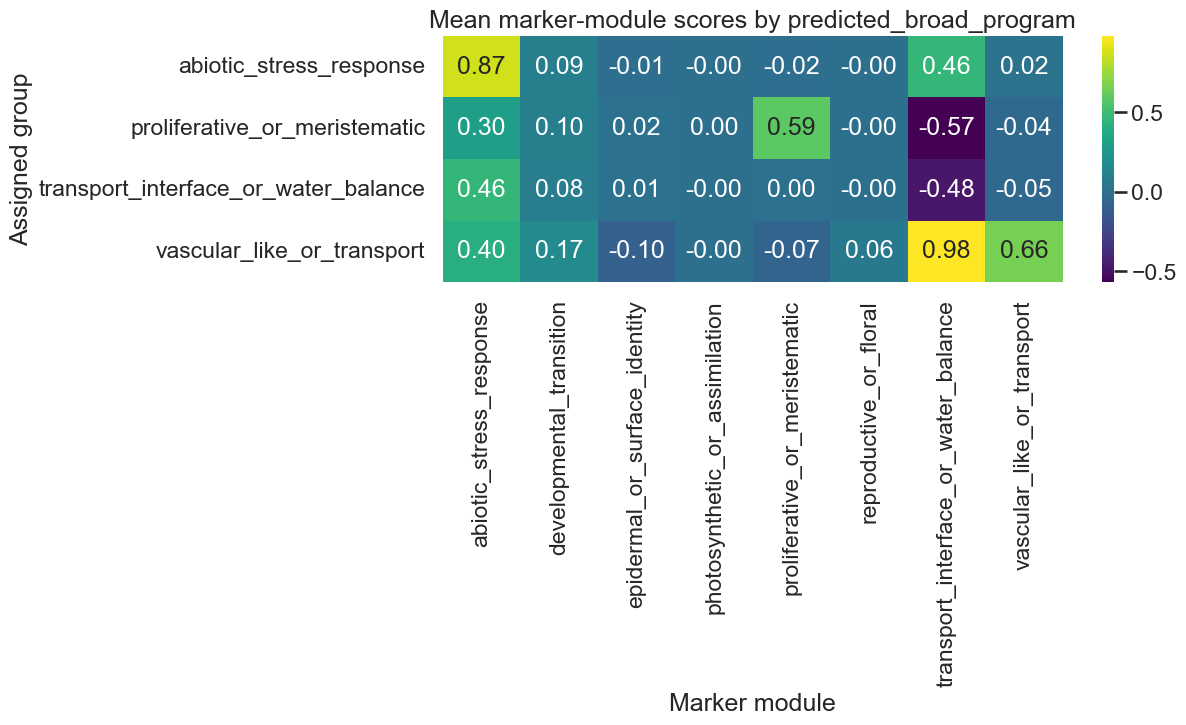

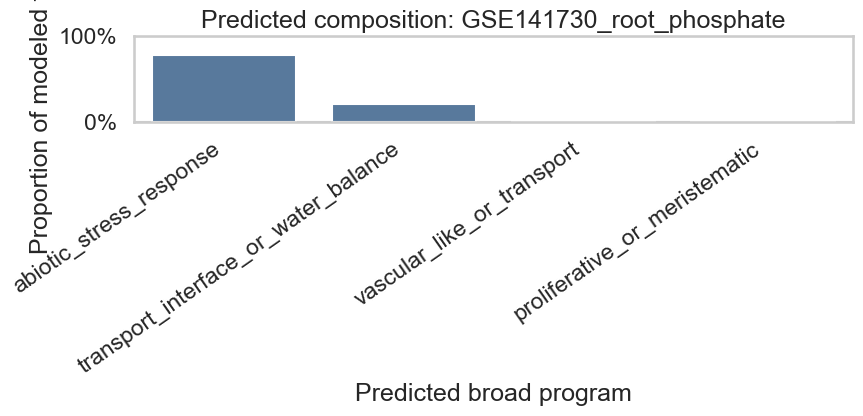

,predicted_broad_program,n_cells,proportion
0,abiotic_stress_response,1557,0.7785
1,transport_interface_or_water_balance,418,0.2090
2,vascular_like_or_transport,16,0.0080
3,proliferative_or_meristematic,9,0.0045


In [11]:
test_score_heatmap = plot_program_heatmap(test_viz, prediction_column)

prediction_proportions = (
    predicted_counts.assign(proportion=lambda frame: frame["n_cells"] / frame["n_cells"].sum())
    .sort_values("proportion", ascending=False)
)
plt.figure(figsize=(9, 4.5))
sns.barplot(data=prediction_proportions, x="predicted_broad_program", y="proportion", color="#4C78A8")
plt.gca().yaxis.set_major_formatter(lambda value, position: f"{value:.0%}")
plt.xticks(rotation=35, ha="right")
plt.xlabel("Predicted broad program")
plt.ylabel("Proportion of modeled test cells")
plt.title(f"Predicted composition: {metrics['test_dataset_name']}")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

display(prediction_proportions)

In [12]:
test_rows = []
for predicted_program, row in test_score_heatmap.iterrows():
    ranked = row.sort_values(ascending=False)
    test_rows.append({
        "predicted_program": predicted_program,
        "highest_scoring_module": ranked.index[0],
        "highest_score": ranked.iloc[0],
        "second_module": ranked.index[1],
        "score_gap": ranked.iloc[0] - ranked.iloc[1],
        "matches_prediction": predicted_program == ranked.index[0],
    })
test_heatmap_check = pd.DataFrame(test_rows)
display(test_heatmap_check)
test_match_rate = test_heatmap_check["matches_prediction"].mean()
minor_share = 1.0 - test_top_share

display(Markdown(f"""
### Interpretation: test scores and composition

- **{test_top_share:.1%}** of modeled test cells receive the dominant `{test_top_label}` prediction; all other programs together account for **{minor_share:.1%}**.
- **{test_match_rate:.0%}** of predicted groups have their matching marker module as the highest group-average score.
- A high matching rate supports internal consistency, but it is not independent validation because marker scores and classifier predictions use related expression information.
- Very small predicted groups should be treated as exploratory until they reproduce across datasets and remain stable under alternative marker sets and model settings.
"""))

,predicted_program,highest_scoring_module,highest_score,second_module,score_gap,matches_prediction
0,abiotic_stress_response,abiotic_stress_response,0.872461,transport_interface_or_water_balance,0.412833,True
1,proliferative_or_meristematic,proliferative_or_meristematic,0.593978,abiotic_stress_response,0.295105,True
2,transport_interface_or_water_balance,abiotic_stress_response,0.460962,developmental_transition,0.379427,False
3,vascular_like_or_transport,transport_interface_or_water_balance,0.982657,vascular_like_or_transport,0.323530,False



### Interpretation: test scores and composition

- **77.8%** of modeled test cells receive the dominant `abiotic_stress_response` prediction; all other programs together account for **22.2%**.
- **50%** of predicted groups have their matching marker module as the highest group-average score.
- A high matching rate supports internal consistency, but it is not independent validation because marker scores and classifier predictions use related expression information.
- Very small predicted groups should be treated as exploratory until they reproduce across datasets and remain stable under alternative marker sets and model settings.


## 6. Direct train-versus-test comparison

This comparison asks whether the predicted test composition resembles the training-label composition. Jensen-Shannon distance ranges from 0 for identical proportions to 1 for completely non-overlapping proportions. A large distance indicates a distribution shift, but does not reveal whether the cause is biology, sampling, treatment, or technical batch effects.

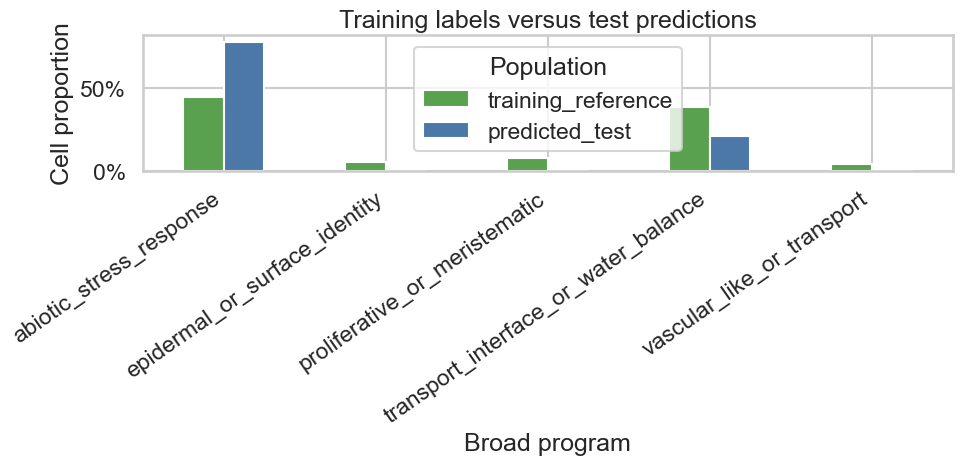

,training_reference,predicted_test
abiotic_stress_response,44.2%,77.8%
epidermal_or_surface_identity,5.4%,0.0%
proliferative_or_meristematic,7.6%,0.4%
transport_interface_or_water_balance,38.6%,20.9%
vascular_like_or_transport,4.1%,0.8%



### Interpretation: train versus test

The Jensen-Shannon distance is **0.34**. The largest proportional shift is for **abiotic_stress_response**, which changes by **+33.6%** from the training reference to the predicted test subset.

This shows that the model is not merely reproducing the training proportions. However, the comparison cannot distinguish a true phosphate-root biological shift from differences in tissue, treatment, platform, sampling, or label-transfer behavior.


In [13]:
train_counts = train_viz.obs["broad_program"].astype(str).value_counts()
test_counts = test_viz.obs[prediction_column].astype(str).value_counts()
all_programs = sorted(set(train_counts.index) | set(test_counts.index))

composition = pd.DataFrame({
    "training_reference": train_counts.reindex(all_programs, fill_value=0),
    "predicted_test": test_counts.reindex(all_programs, fill_value=0),
}).astype(float)
composition = composition.div(composition.sum(axis=0), axis=1)

composition.plot(kind="bar", figsize=(10, 5), color=["#59A14F", "#4C78A8"])
plt.ylabel("Cell proportion")
plt.xlabel("Broad program")
plt.title("Training labels versus test predictions")
plt.gca().yaxis.set_major_formatter(lambda value, position: f"{value:.0%}")
plt.xticks(rotation=35, ha="right")
plt.legend(title="Population")
plt.tight_layout()
plt.show()

display(composition.style.format("{:.1%}"))
js_distance = float(jensenshannon(composition["training_reference"], composition["predicted_test"], base=2))
largest_shift = (composition["predicted_test"] - composition["training_reference"]).abs().idxmax()
shift_value = composition.loc[largest_shift, "predicted_test"] - composition.loc[largest_shift, "training_reference"]

display(Markdown(f"""
### Interpretation: train versus test

The Jensen-Shannon distance is **{js_distance:.2f}**. The largest proportional shift is for **{largest_shift}**, which changes by **{shift_value:+.1%}** from the training reference to the predicted test subset.

This shows that the model is not merely reproducing the training proportions. However, the comparison cannot distinguish a true phosphate-root biological shift from differences in tissue, treatment, platform, sampling, or label-transfer behavior.
"""))

### Marker recovery across datasets

A program cannot be transferred reliably when most of its marker genes are absent from a dataset. The chart below compares the fraction of requested markers found in the training and test feature sets. Low recovery weakens both program scores and biological interpretation.

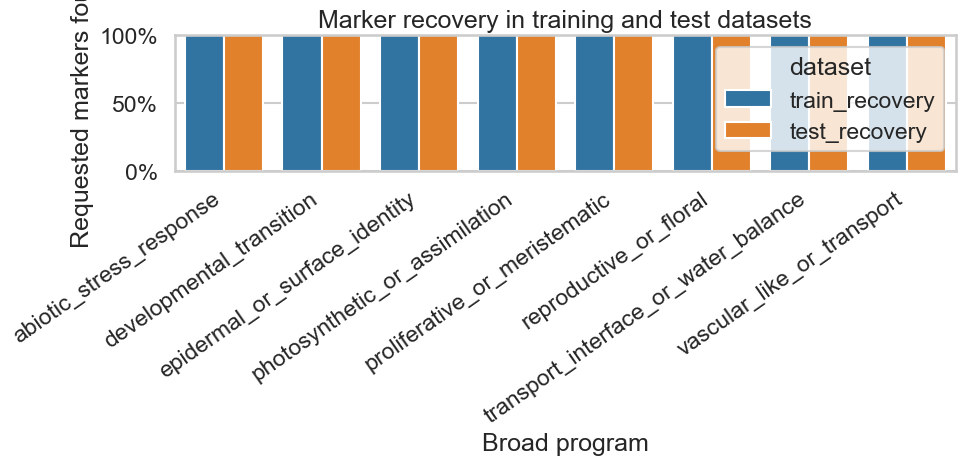

,program,n_input_markers,train_markers_found,test_markers_found,train_recovery,test_recovery
0,abiotic_stress_response,6,6,6,100%,100%
1,developmental_transition,6,6,6,100%,100%
2,epidermal_or_surface_identity,5,5,5,100%,100%
3,photosynthetic_or_assimilation,6,6,6,100%,100%
4,proliferative_or_meristematic,5,5,5,100%,100%
5,reproductive_or_floral,3,3,3,100%,100%
6,transport_interface_or_water_balance,5,5,5,100%,100%
7,vascular_like_or_transport,9,9,9,100%,100%


In [14]:
marker_comparison = train_marker_recovery[["program", "n_input_markers", "n_markers_found"]].rename(
    columns={"n_markers_found": "train_markers_found"}
).merge(
    test_marker_recovery[["program", "n_markers_found"]].rename(columns={"n_markers_found": "test_markers_found"}),
    on="program",
    how="outer",
)
marker_comparison["train_recovery"] = marker_comparison["train_markers_found"] / marker_comparison["n_input_markers"]
marker_comparison["test_recovery"] = marker_comparison["test_markers_found"] / marker_comparison["n_input_markers"]

marker_long = marker_comparison.melt(
    id_vars="program",
    value_vars=["train_recovery", "test_recovery"],
    var_name="dataset",
    value_name="marker_recovery",
)
plt.figure(figsize=(10, 5))
sns.barplot(data=marker_long, x="program", y="marker_recovery", hue="dataset")
plt.ylim(0, 1)
plt.gca().yaxis.set_major_formatter(lambda value, position: f"{value:.0%}")
plt.xticks(rotation=35, ha="right")
plt.ylabel("Requested markers found")
plt.xlabel("Broad program")
plt.title("Marker recovery in training and test datasets")
plt.tight_layout()
plt.show()

display(marker_comparison.style.format({"train_recovery": "{:.0%}", "test_recovery": "{:.0%}"}))

## 7. Compare all completed Arabidopsis transfers

One transfer can be misleading. This section compares every saved `results/public_reference*` run using prediction proportions. It includes callus-trained transfers to several root datasets and root-trained sensitivity analyses.

This is particularly important for the future Wolffia analysis: a program should be considered more credible when it is stable across reasonable reference choices, not only when one model predicts it strongly.

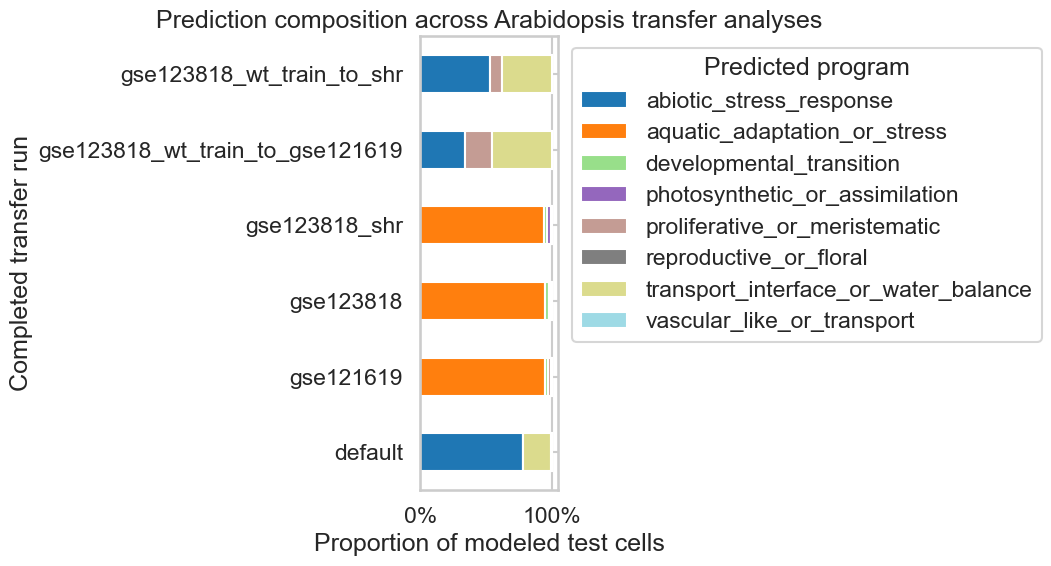

,run,train_dataset,test_dataset,dominant_prediction,dominant_share,n_programs_at_least_1pct
0,default,GSE227564_callus,GSE141730_root_phosphate,abiotic_stress_response,77.8%,2
1,gse121619,GSE227564_callus,GSE121619_all_root,aquatic_adaptation_or_stress,95.0%,3
2,gse123818,GSE227564_callus,GSE123818_wt_root,aquatic_adaptation_or_stress,95.2%,3
3,gse123818_shr,GSE227564_callus,GSE123818_shr_root,aquatic_adaptation_or_stress,94.4%,3
4,gse123818_wt_train_to_gse121619,GSE123818_wt_root,GSE121619_all_root,transport_interface_or_water_balance,45.4%,3
5,gse123818_wt_train_to_shr,GSE123818_wt_root,GSE123818_shr_root,abiotic_stress_response,53.2%,3


In [15]:
comparison_rows = []
for result_dir in AVAILABLE_RESULT_DIRS:
    metrics_path = result_dir / "cross_dataset_metrics.json"
    counts_path = result_dir / "predicted_label_counts.csv"
    if not metrics_path.exists() or not counts_path.exists():
        continue
    with open(metrics_path) as fh:
        run_metrics = json.load(fh)
    run_counts = pd.read_csv(counts_path)
    total_cells = int(run_counts["n_cells"].sum())
    for row in run_counts.itertuples(index=False):
        comparison_rows.append({
            "run": result_dir.name.removeprefix("public_reference").lstrip("_") or "default",
            "train_dataset": run_metrics["train_dataset_name"],
            "test_dataset": run_metrics["test_dataset_name"],
            "program": row.predicted_broad_program,
            "n_cells": int(row.n_cells),
            "proportion": row.n_cells / total_cells,
        })

cross_run = pd.DataFrame(comparison_rows)
run_order = cross_run[["run", "train_dataset", "test_dataset"]].drop_duplicates()["run"].tolist()
comparison_pivot = cross_run.pivot_table(index="run", columns="program", values="proportion", fill_value=0).reindex(run_order)

comparison_pivot.plot(kind="barh", stacked=True, figsize=(11, 6), colormap="tab20")
plt.xlabel("Proportion of modeled test cells")
plt.ylabel("Completed transfer run")
plt.title("Prediction composition across Arabidopsis transfer analyses")
plt.gca().xaxis.set_major_formatter(lambda value, position: f"{value:.0%}")
plt.legend(title="Predicted program", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

run_summary = (
    cross_run.sort_values(["run", "proportion"], ascending=[True, False])
    .groupby("run", as_index=False)
    .first()[["run", "train_dataset", "test_dataset", "program", "proportion"]]
    .rename(columns={"program": "dominant_prediction", "proportion": "dominant_share"})
)
run_summary["n_programs_at_least_1pct"] = run_summary["run"].map(
    cross_run[cross_run["proportion"] >= 0.01].groupby("run")["program"].nunique()
)
display(run_summary.style.format({"dominant_share": "{:.1%}"}))

In [16]:
callus_runs = run_summary[run_summary["train_dataset"].str.contains("GSE227564", na=False)]
root_runs = run_summary[~run_summary["train_dataset"].str.contains("GSE227564", na=False)]
callus_dominance = callus_runs["dominant_share"].median() if not callus_runs.empty else np.nan
root_dominance = root_runs["dominant_share"].median() if not root_runs.empty else np.nan

most_balanced = run_summary.loc[run_summary["dominant_share"].idxmin()]
most_dominated = run_summary.loc[run_summary["dominant_share"].idxmax()]

display(Markdown(f"""
### Interpretation: cross-run comparison

- The most dominated run is **{most_dominated['run']}**, where **{most_dominated['dominant_prediction']}** accounts for **{most_dominated['dominant_share']:.1%}** of predictions.
- The most balanced run by this simple measure is **{most_balanced['run']}**, whose largest program accounts for **{most_balanced['dominant_share']:.1%}**.
- Median dominant-program share is **{callus_dominance:.1%}** for the callus-trained runs and **{root_dominance:.1%}** for the root-trained sensitivity runs.

The large change in prediction composition after changing the training reference is evidence that **reference choice materially affects transfer results**. The repeated dominance seen in several callus-to-root runs is therefore not sufficient evidence that the corresponding program truly dominates root biology. Tissue mismatch and reference construction are plausible alternative explanations.
"""))


### Interpretation: cross-run comparison

- The most dominated run is **gse123818**, where **aquatic_adaptation_or_stress** accounts for **95.2%** of predictions.
- The most balanced run by this simple measure is **gse123818_wt_train_to_gse121619**, whose largest program accounts for **45.4%**.
- Median dominant-program share is **94.7%** for the callus-trained runs and **49.3%** for the root-trained sensitivity runs.

The large change in prediction composition after changing the training reference is evidence that **reference choice materially affects transfer results**. The repeated dominance seen in several callus-to-root runs is therefore not sufficient evidence that the corresponding program truly dominates root biology. Tissue mismatch and reference construction are plausible alternative explanations.


## 8. Conclusions and implications for Wolffia

### What the current analysis supports

- The workflow can train on one Arabidopsis dataset and generate reproducible broad-program predictions in independent datasets.
- Some predicted programs occupy coherent expression neighborhoods and show matching marker-module activity.
- Prediction composition changes substantially across training references, demonstrating that reference selection is a major source of uncertainty.

### What it does not yet establish

- It does not prove that predicted programs are true cell types in the unlabeled test dataset.
- It does not show that Wolffia contains the same cell identities as Arabidopsis.
- A dominant prediction does not by itself show biological dominance; it can result from treatment, tissue mismatch, technical batch effects, marker-panel limitations, or model bias.

### How this informs the future Wolffia PIP-seq analysis

A Wolffia program will be strongest when it is supported by several independent signals: conserved orthologous markers, coherent UMAP localization, a clear program-score margin, stability across multiple Arabidopsis references, and experimental or spatial validation. Possible outcomes include preserved programs, weakly separable programs, merged or compressed states, and missing or ambiguous mappings.

**Current confidence: share with caveats.** The workflow and plots are suitable for discussing hypotheses and analysis design, but biological claims should wait for stronger validation and the Wolffia data.